# 2. What the star does to the data

A starspot rotating across the disk pulls the photocenter around and dims
the star. This tutorial simulates both observables — the **astrometric
jitter** (photocenter x, y) and the **light curve** — and shows how their
shapes depend on the star's inclination and the spot's latitude. These are
the patterns the inverse problem will read the surface from.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jittermap as jm
from jittermap.plotting.render import build_projection_grid, render_surface_fast
from jittermap.plotting.panels import render_panel, normalize_map
GRID = build_projection_grid(n_grid=200)
X, Y, Z, THETA, PHI, MASK = GRID

def show_star(ax, coeffs, l_max, beta, title="", t=0.0):
    m = render_surface_fast(coeffs, l_max, beta, THETA, PHI, MASK, X, Y, Z, t=t)
    render_panel(ax, normalize_map(m), title, beta)
    ax.set_xticks([]); ax.set_yticks([])


In [2]:
L, N = 15, 200
times = np.linspace(0, 2*np.pi, N, endpoint=False)
star = jm.multispot_surface([(35, 300, 12.0)], L)   # one spot, latitude 35
fm = jm.ForwardModel(times, l_max=L)

## The star and its jitter, side by side

The paper's Figure 2, recreated: the spotted star (left) and the closed
curve its photocenter traces over one rotation (right), for inclinations
from equator-on to pole-on.

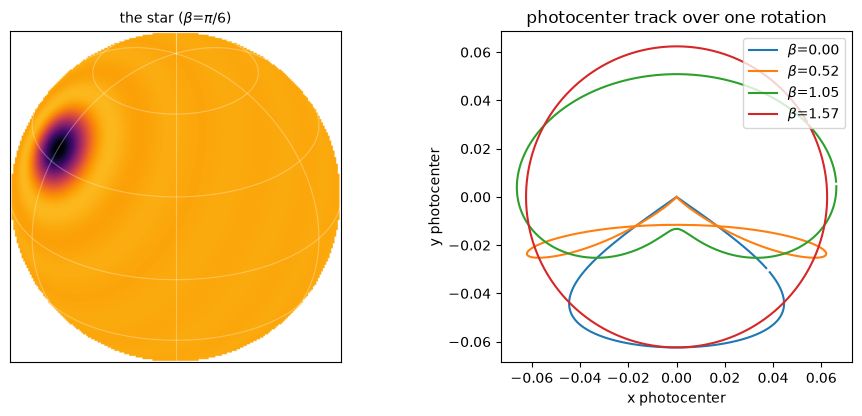

In [3]:
betas = [0.0, np.pi/6, np.pi/3, np.pi/2]
fig = plt.figure(figsize=(9.5, 4.2))
ax_star = fig.add_subplot(1, 2, 1)
show_star(ax_star, star, L, np.pi/6, "the star ($\\beta$=$\\pi$/6)")
ax = fig.add_subplot(1, 2, 2)
for beta in betas:
    y = fm.observe(star, inclination=beta, channels="xy", stacked=False)
    ax.plot(y["x"], y["y"], label=f"$\\beta$={beta:.2f}")
ax.set_xlabel("x photocenter"); ax.set_ylabel("y photocenter")
ax.set_title("photocenter track over one rotation")
ax.set_aspect("equal"); ax.legend()
plt.tight_layout()

Two things to notice, both derived in the paper:

* While the spot is hidden behind the star the photocenter sits still at
  the origin — the cusp is spot egress/ingress.
* **Pole-on, the jitter of any surface is a perfect circle.** Rotation then
  only spins the picture without changing what is visible, so the shape of
  the track carries no surface information: pole-on stars are the worst
  case for mapping.

## The three data channels together

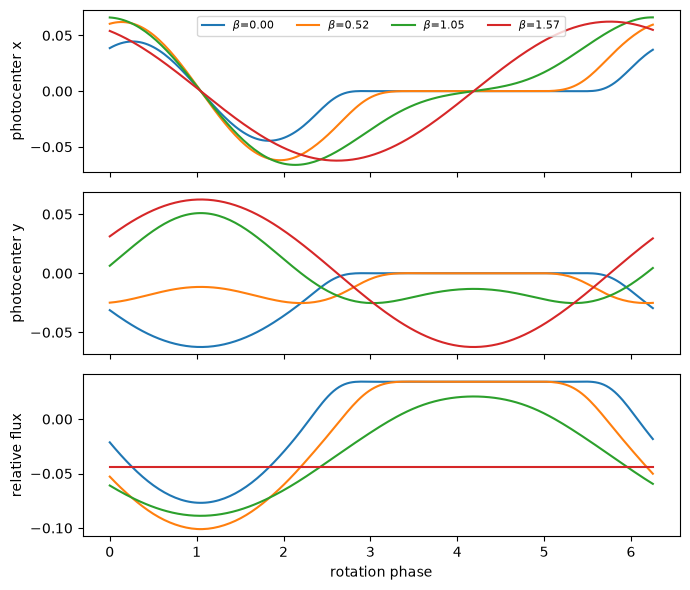

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(7, 6), sharex=True)
for beta in betas:
    y = fm.observe(star, inclination=beta, channels="xyp", stacked=False)
    for ax, c, name in zip(axes, "xyp", ["photocenter x", "photocenter y",
                                          "relative flux"]):
        ax.plot(times, y[c], label=f"$\\beta$={beta:.2f}")
        ax.set_ylabel(name)
axes[0].legend(ncol=4, fontsize=8); axes[-1].set_xlabel("rotation phase")
plt.tight_layout()

The light-curve modulation *shrinks* toward pole-on (the spot never leaves
the visible disk) while the jitter amplitude grows — astrometry and
photometry degrade in opposite regimes, a first hint of their
complementarity.

## Spot latitude

At a fixed viewing angle ($\beta = 30°$, paper Fig. 3), the latitude of
the spot reshapes the track — high-latitude spots make smaller excursions.
This is how astrometry localizes spots in latitude, something a light
curve struggles to do:

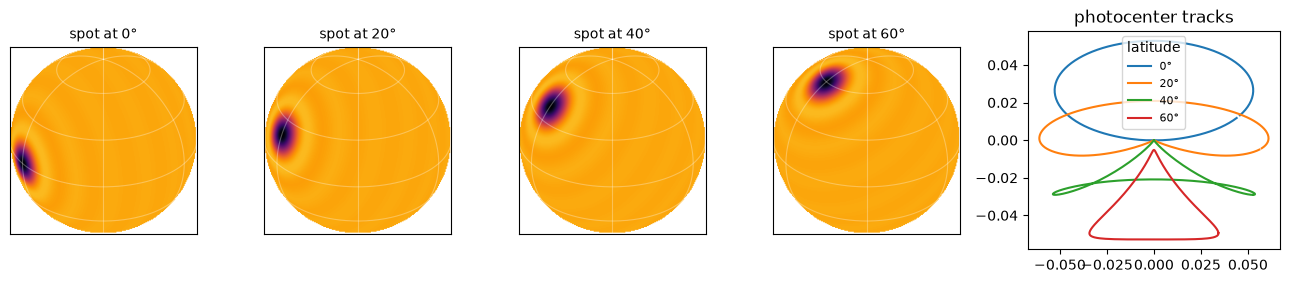

In [5]:
beta = np.pi/6
lats = [0, 20, 40, 60]
fig, axes = plt.subplots(1, 5, figsize=(13, 3),
                         gridspec_kw={"width_ratios": [1, 1, 1, 1, 1.35]})
for ax, lat in zip(axes[:4], lats):
    s_lat = jm.multispot_surface([(lat, 300, jm.rfrac_to_deg(0.10))], L)
    show_star(ax, s_lat, L, beta, f"spot at {lat}°")
for lat in lats:
    s_lat = jm.multispot_surface([(lat, 300, jm.rfrac_to_deg(0.10))], L)
    y = fm.observe(s_lat, inclination=beta, channels="xy", stacked=False)
    axes[4].plot(y["x"], y["y"], label=f"{lat}°")
axes[4].set_aspect("equal"); axes[4].legend(title="latitude", fontsize=8)
axes[4].set_title("photocenter tracks")
plt.tight_layout()

## For the curious: the model is exactly linear

Behind `ForwardModel` is a design matrix acting on the coefficient vector,
$\boldsymbol{\mu} = A(\beta)\,\mathbf{s}$, assembled through
precomputed Wigner rotation tables (shipped to $L=40$) — see the *Model and
background* page for the math. A slow reference implementation is kept
around purely to check the fast one:

In [6]:
from jittermap.forward.design import design_matrix_reference, \
    design_matrix_vandermonde, precompute_vandermonde
from jittermap.forward.kernels import compute_A_lm

A_x, A_y = compute_A_lm(L)
D_ref = design_matrix_reference(times, L, 0.6, A_x)
D_fast = design_matrix_vandermonde(L, 0.6, A_x, *precompute_vandermonde(times, L))
print("fast path matches reference:", np.allclose(D_ref, D_fast))

fast path matches reference: True
